In [3]:
# ============================================================
# CELL 1: Setup SQL environment
# ============================================================

# Install pandasql if not already installed
!pip install pandasql

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf
import warnings
warnings.filterwarnings('ignore')


# Mount Drive and load data
from google.colab import drive
drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/podcast_analytics'
df = pd.read_csv(f'{project_path}/USvideos_cleaned.csv')

# pandasql needs a function that knows about your dataframes
pysql = lambda q: sqldf(q, globals())

# Set visual style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']       = 130
plt.rcParams['figure.facecolor'] = 'white'

print(f"SQL environment ready.")
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nAvailable table: 'df'")
print(f"Key columns: video_id, title_clean, category_name,")
print(f"             views, likes, engagement_rate,")
print(f"             days_to_trend, publish_day_of_week")

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=d6918109b686fad21a9600180b339059bc476ba6b4cd061aea58b352db54d710
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql
Mounted at /content/drive
SQL environment ready.
Dataset: 6,351 rows × 30 columns

Available table: 'df'
Key columns: video_id, title_clean, category_name,
             views, likes, engagement_rate,
             days_to_trend, publish_day_of_week


In [4]:
# ============================================================
# CELL 2: Q1 — Category performance ranked (business overview)
# ============================================================

query_1 = """
SELECT
    category_name,
    COUNT(*)                          AS total_videos,
    ROUND(AVG(views), 0)              AS avg_views,
    ROUND(AVG(likes), 0)              AS avg_likes,
    ROUND(AVG(engagement_rate), 2)    AS avg_engagement_pct,
    ROUND(AVG(days_to_trend), 1)      AS avg_days_to_trend,
    ROUND(AVG(like_rate), 2)          AS avg_like_rate_pct,

    -- Performance tier based on avg views
    CASE
        WHEN AVG(views) >= 1000000 THEN 'Tier 1 — High reach'
        WHEN AVG(views) >= 500000  THEN 'Tier 2 — Mid reach'
        ELSE                            'Tier 3 — Lower reach'
    END AS reach_tier

FROM df
WHERE category_name IS NOT NULL
GROUP BY category_name
HAVING COUNT(*) >= 20          -- exclude tiny categories
ORDER BY avg_views DESC
"""

q1_result = pysql(query_1)
print("QUERY 1 — Category Performance Ranked by Avg Views")
print("=" * 60)
print(q1_result.to_string(index=False))

# Save for dashboard use later
q1_result.to_csv(f'{project_path}/sql_q1_category_performance.csv',
                 index=False)
print("\nSaved to Drive.")

QUERY 1 — Category Performance Ranked by Avg Views
       category_name  total_videos  avg_views  avg_likes  avg_engagement_pct  avg_days_to_trend  avg_like_rate_pct           reach_tier
               Music           801  6027699.0   188067.0                4.61               30.1               4.15  Tier 1 — High reach
    Film & Animation           320  2578968.0    53248.0                3.01               78.4               2.53  Tier 1 — High reach
              Gaming           103  2325087.0    67877.0                4.10               48.9               3.29  Tier 1 — High reach
       Entertainment          1621  1744890.0    41601.0                3.05               23.6               2.54  Tier 1 — High reach
    Autos & Vehicles            71  1449487.0    10286.0                1.77               75.6               1.41  Tier 1 — High reach
              Sports           449  1424202.0    28031.0                1.68               24.2               1.32  Tier 1 — High rea

In [5]:
# ============================================================
# CELL 3: Q2 — Which channels consistently produce high performers?
# ============================================================

query_2 = """
SELECT
    channel_title,
    COUNT(*)                              AS videos_trending,
    ROUND(AVG(views), 0)                  AS avg_views,
    ROUND(AVG(engagement_rate), 2)        AS avg_engagement_pct,
    MAX(views)                            AS peak_views,
    ROUND(MIN(views), 0)                  AS floor_views,

    -- Consistency score: how close is avg to peak?
    -- A score near 1.0 means every video performs like the best one
    ROUND(CAST(AVG(views) AS FLOAT) / MAX(views), 3) AS consistency_score

FROM df
WHERE category_name IS NOT NULL
GROUP BY channel_title
HAVING COUNT(*) >= 3           -- only channels with 3+ trending videos
ORDER BY consistency_score DESC, avg_views DESC
LIMIT 20
"""

q2_result = pysql(query_2)
print("QUERY 2 — Most Consistent Channels (3+ trending videos)")
print("=" * 60)
print(q2_result.to_string(index=False))

q2_result.to_csv(f'{project_path}/sql_q2_top_channels.csv', index=False)

QUERY 2 — Most Consistent Channels (3+ trending videos)
       channel_title  videos_trending  avg_views  avg_engagement_pct  peak_views  floor_views  consistency_score
Primitive Technology                3  4309701.0                3.98     4430776    4209089.0              0.973
              DanTDM                3  1697106.0                7.16     1747746    1666684.0              0.971
             Jenn Im                3   265832.0                6.33      281689     243232.0              0.944
         3Blue1Brown                3   283050.0                5.82      302153     248330.0              0.937
      Liza Koshy Too                4  2911229.0                7.81     3187327    2592896.0              0.913
        Hunter Hayes                3   102933.0                3.39      112866      95044.0              0.912
     SmarterEveryDay                3   679432.0                5.16      747391     554157.0              0.909
       Ingrid Nilsen                3   

In [6]:
# ============================================================
# CELL 4: Q3 — The engagement paradox (views vs quality)
# ============================================================

query_3 = """
WITH video_tiers AS (
    SELECT
        video_id,
        title_clean,
        category_name,
        views,
        likes,
        engagement_rate,
        like_rate,

        -- Divide videos into view quartiles
        CASE
            WHEN views >= 5000000  THEN 'Viral (5M+)'
            WHEN views >= 1000000  THEN 'Hit (1M–5M)'
            WHEN views >= 500000   THEN 'Strong (500K–1M)'
            ELSE                        'Average (under 500K)'
        END AS view_tier,

        -- Divide videos into engagement quartiles
        CASE
            WHEN engagement_rate >= 10 THEN 'Very high (10%+)'
            WHEN engagement_rate >= 5  THEN 'High (5–10%)'
            WHEN engagement_rate >= 2  THEN 'Medium (2–5%)'
            ELSE                            'Low (under 2%)'
        END AS engagement_tier

    FROM df
    WHERE views > 0
)

SELECT
    view_tier,
    engagement_tier,
    COUNT(*)                           AS video_count,
    ROUND(AVG(views) / 1000000.0, 2)  AS avg_views_M,
    ROUND(AVG(engagement_rate), 2)    AS avg_eng_pct,
    ROUND(AVG(like_rate), 2)          AS avg_like_rate_pct

FROM video_tiers
GROUP BY view_tier, engagement_tier
ORDER BY
    CASE view_tier
        WHEN 'Viral (5M+)'           THEN 1
        WHEN 'Hit (1M–5M)'           THEN 2
        WHEN 'Strong (500K–1M)'      THEN 3
        ELSE 4
    END,
    avg_eng_pct DESC
"""

q3_result = pysql(query_3)
print("QUERY 3 — The Engagement Paradox: Views vs Quality")
print("=" * 60)
print(q3_result.to_string(index=False))

# Key insight extraction
viral_low = q3_result[
    (q3_result['view_tier'] == 'Viral (5M+)') &
    (q3_result['engagement_tier'] == 'Low (under 2%)')
]
if len(viral_low) > 0:
    print(f"\nKEY FINDING: {viral_low['video_count'].values[0]} viral videos"
          f" have LOW engagement — reach without connection.")

q3_result.to_csv(f'{project_path}/sql_q3_engagement_paradox.csv', index=False)

QUERY 3 — The Engagement Paradox: Views vs Quality
           view_tier  engagement_tier  video_count  avg_views_M  avg_eng_pct  avg_like_rate_pct
         Viral (5M+) Very high (10%+)           19        13.32        13.63              11.17
         Viral (5M+)     High (5–10%)           48        12.10         6.57               5.71
         Viral (5M+)    Medium (2–5%)          239        17.19         3.25               2.87
         Viral (5M+)   Low (under 2%)          146        17.21         1.11               0.93
         Hit (1M–5M) Very high (10%+)           64         2.03        13.05              10.15
         Hit (1M–5M)     High (5–10%)          337         2.17         6.75               5.93
         Hit (1M–5M)    Medium (2–5%)          822         2.14         3.28               2.83
         Hit (1M–5M)   Low (under 2%)          501         2.13         1.22               0.98
    Strong (500K–1M) Very high (10%+)           24         0.77        12.40         

QUERY 4 — Performance by Day of Week Published
day_published  videos  avg_views  avg_engagement_pct  avg_days_to_trend  views_rank  engagement_rank
       Friday    1047  2864179.0                3.58               25.7           1                3
       Sunday     559  2122530.0                3.43               54.9           2                6
     Thursday    1056  2102151.0                3.57               25.3           3                4
       Monday     985  1698366.0                3.29               25.8           4                7
    Wednesday    1097  1669424.0                3.63               11.7           5                2
      Tuesday    1060  1606184.0                3.54               32.9           6                5
     Saturday     547  1573054.0                3.68               40.5           7                1


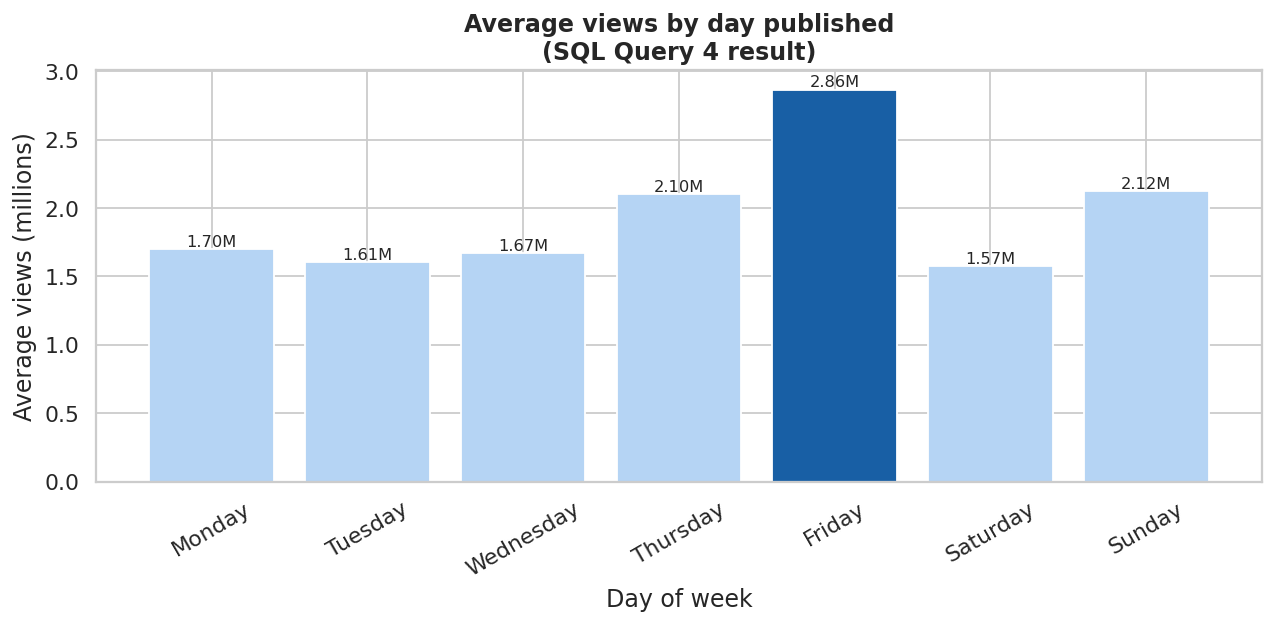

In [7]:
# ============================================================
# CELL 5: Q4 — Best time to publish for maximum views
# ============================================================

query_4 = """
SELECT
    publish_day_of_week                         AS day_published,
    COUNT(*)                                    AS videos,
    ROUND(AVG(views), 0)                        AS avg_views,
    ROUND(AVG(engagement_rate), 2)              AS avg_engagement_pct,
    ROUND(AVG(days_to_trend), 1)                AS avg_days_to_trend,

    -- Rank days by avg views within this query
    RANK() OVER (ORDER BY AVG(views) DESC)      AS views_rank,
    RANK() OVER (ORDER BY AVG(engagement_rate) DESC) AS engagement_rank

FROM df
WHERE publish_day_of_week IS NOT NULL
GROUP BY publish_day_of_week
ORDER BY avg_views DESC
"""

q4_result = pysql(query_4)
print("QUERY 4 — Performance by Day of Week Published")
print("=" * 60)
print(q4_result.to_string(index=False))

# Visualise this result
fig, ax = plt.subplots(figsize=(10, 5))

day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
q4_plot = q4_result.set_index('day_published').reindex(day_order)

colors = ['#185FA5' if v == q4_plot['avg_views'].max()
          else '#B5D4F4' for v in q4_plot['avg_views']]

bars = ax.bar(q4_plot.index, q4_plot['avg_views'] / 1e6,
              color=colors, edgecolor='white')
ax.set_title('Average views by day published\n(SQL Query 4 result)',
             fontweight='bold')
ax.set_xlabel('Day of week')
ax.set_ylabel('Average views (millions)')
ax.tick_params(axis='x', rotation=30)

for bar, val in zip(bars, q4_plot['avg_views']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{val/1e6:.2f}M',
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{project_path}/sql_plot_timing.png',
            bbox_inches='tight', dpi=150)
plt.show()

q4_result.to_csv(f'{project_path}/sql_q4_timing.csv', index=False)

In [8]:
# ============================================================
# CELL 6: Q5 — Does trending speed predict sustained performance?
# ============================================================

query_5 = """
WITH speed_segments AS (
    SELECT
        video_id,
        title_clean,
        category_name,
        views,
        likes,
        engagement_rate,
        days_to_trend,

        CASE
            WHEN days_to_trend = 0  THEN '1. Same day'
            WHEN days_to_trend <= 2 THEN '2. Within 2 days'
            WHEN days_to_trend <= 7 THEN '3. Within a week'
            WHEN days_to_trend <= 14 THEN '4. Within 2 weeks'
            ELSE                         '5. Slow burn (15+ days)'
        END AS speed_bucket

    FROM df
    WHERE days_to_trend >= 0
      AND days_to_trend <= 30
)

SELECT
    speed_bucket,
    COUNT(*)                          AS videos,
    ROUND(AVG(views), 0)              AS avg_views,
    ROUND(AVG(engagement_rate), 2)    AS avg_engagement_pct,
    ROUND(AVG(likes), 0)              AS avg_likes,

    -- What % of this segment are in the top 10% of views overall?
    ROUND(
        100.0 * SUM(CASE WHEN views >= 1963852 THEN 1 ELSE 0 END)
        / COUNT(*), 1
    )                                 AS pct_above_avg_views

FROM speed_segments
GROUP BY speed_bucket
ORDER BY speed_bucket
"""

q5_result = pysql(query_5)
print("QUERY 5 — Virality Speed Segments vs Performance")
print("=" * 60)
print(q5_result.to_string(index=False))

q5_result.to_csv(f'{project_path}/sql_q5_virality_speed.csv', index=False)

QUERY 5 — Virality Speed Segments vs Performance
           speed_bucket  videos  avg_views  avg_engagement_pct  avg_likes  pct_above_avg_views
            1. Same day      17   442076.0                5.45     8529.0                  5.9
       2. Within 2 days     615   724819.0                2.96    21199.0                  9.4
       3. Within a week    3263  1111689.0                3.71    36681.0                 13.5
      4. Within 2 weeks    1660  2504691.0                3.63    75014.0                 24.5
5. Slow burn (15+ days)     687  5884880.0                3.29   136342.0                 46.7


In [9]:
# ============================================================
# CELL 7: Q6 — News vs Music — full SQL comparison
# ============================================================

query_6 = """
SELECT
    category_name,
    COUNT(*)                               AS videos,
    ROUND(AVG(views), 0)                   AS avg_views,
    ROUND(AVG(engagement_rate), 2)         AS avg_engagement_pct,
    ROUND(AVG(days_to_trend), 1)           AS avg_days_to_trend,
    ROUND(AVG(title_length), 1)            AS avg_title_length,

    -- What share of each category goes viral (5M+ views)?
    ROUND(
        100.0 * SUM(CASE WHEN views >= 5000000 THEN 1 ELSE 0 END)
        / COUNT(*), 1
    )                                      AS viral_rate_pct,

    -- What share has low engagement (under 2%)?
    ROUND(
        100.0 * SUM(CASE WHEN engagement_rate < 2 THEN 1 ELSE 0 END)
        / COUNT(*), 1
    )                                      AS low_engagement_rate_pct

FROM df
WHERE category_name IN ('Music', 'News & Politics',
                        'Entertainment', 'Gaming', 'Comedy')
GROUP BY category_name
ORDER BY avg_views DESC
"""

q6_result = pysql(query_6)
print("QUERY 6 — Head-to-head: top 5 categories")
print("=" * 60)
print(q6_result.to_string(index=False))

q6_result.to_csv(f'{project_path}/sql_q6_head_to_head.csv', index=False)

QUERY 6 — Head-to-head: top 5 categories
  category_name  videos  avg_views  avg_engagement_pct  avg_days_to_trend  avg_title_length  viral_rate_pct  low_engagement_rate_pct
          Music     801  6027699.0                4.61               30.1              45.8            22.2                     17.4
         Gaming     103  2325087.0                4.10               48.9              47.2            10.7                     15.5
  Entertainment    1621  1744890.0                3.05               23.6              53.2             6.5                     40.5
         Comedy     544  1422561.0                4.40               16.4              43.4             4.6                     27.8
News & Politics     504   459935.0                2.24               19.2              57.7             0.8                     59.3


In [10]:
# ============================================================
# CELL 8: Export all queries to a .sql file for GitHub
# ============================================================

sql_file_content = """
-- ============================================================
-- YouTube Trending Video Analytics — SQL Queries
-- Author: [Your Name]
-- Dataset: YouTube Trending Videos (USvideos.csv)
-- Tool: SQLite via pandasql in Google Colab
-- ============================================================


-- Q1: Category Performance Ranked
-- Business question: Which content categories reach the most viewers?
SELECT
    category_name,
    COUNT(*)                          AS total_videos,
    ROUND(AVG(views), 0)              AS avg_views,
    ROUND(AVG(engagement_rate), 2)    AS avg_engagement_pct,
    ROUND(AVG(days_to_trend), 1)      AS avg_days_to_trend,
    CASE
        WHEN AVG(views) >= 1000000 THEN 'Tier 1 — High reach'
        WHEN AVG(views) >= 500000  THEN 'Tier 2 — Mid reach'
        ELSE                            'Tier 3 — Lower reach'
    END AS reach_tier
FROM df
WHERE category_name IS NOT NULL
GROUP BY category_name
HAVING COUNT(*) >= 20
ORDER BY avg_views DESC;


-- Q2: Most Consistent Channels
-- Business question: Which channels reliably produce trending videos?
SELECT
    channel_title,
    COUNT(*)                                               AS videos_trending,
    ROUND(AVG(views), 0)                                   AS avg_views,
    ROUND(CAST(AVG(views) AS FLOAT) / MAX(views), 3)       AS consistency_score
FROM df
GROUP BY channel_title
HAVING COUNT(*) >= 3
ORDER BY consistency_score DESC, avg_views DESC
LIMIT 20;


-- Q3: Engagement Paradox (CTE)
-- Business question: Do high-view videos also have high engagement?
WITH video_tiers AS (
    SELECT
        views,
        engagement_rate,
        CASE
            WHEN views >= 5000000  THEN 'Viral (5M+)'
            WHEN views >= 1000000  THEN 'Hit (1M-5M)'
            WHEN views >= 500000   THEN 'Strong (500K-1M)'
            ELSE                        'Average (under 500K)'
        END AS view_tier,
        CASE
            WHEN engagement_rate >= 10 THEN 'Very high (10%+)'
            WHEN engagement_rate >= 5  THEN 'High (5-10%)'
            WHEN engagement_rate >= 2  THEN 'Medium (2-5%)'
            ELSE                            'Low (under 2%)'
        END AS engagement_tier
    FROM df WHERE views > 0
)
SELECT
    view_tier, engagement_tier,
    COUNT(*) AS video_count,
    ROUND(AVG(engagement_rate), 2) AS avg_eng_pct
FROM video_tiers
GROUP BY view_tier, engagement_tier
ORDER BY avg_eng_pct DESC;


-- Q4: Publishing Timing (Window Functions)
-- Business question: Does day of publishing affect performance?
SELECT
    publish_day_of_week,
    COUNT(*)                                         AS videos,
    ROUND(AVG(views), 0)                             AS avg_views,
    RANK() OVER (ORDER BY AVG(views) DESC)           AS views_rank,
    RANK() OVER (ORDER BY AVG(engagement_rate) DESC) AS engagement_rank
FROM df
WHERE publish_day_of_week IS NOT NULL
GROUP BY publish_day_of_week
ORDER BY avg_views DESC;


-- Q5: Virality Speed Segments
-- Business question: Does trending faster lead to more total views?
WITH speed_segments AS (
    SELECT views, engagement_rate, days_to_trend,
        CASE
            WHEN days_to_trend = 0   THEN '1. Same day'
            WHEN days_to_trend <= 2  THEN '2. Within 2 days'
            WHEN days_to_trend <= 7  THEN '3. Within a week'
            WHEN days_to_trend <= 14 THEN '4. Within 2 weeks'
            ELSE                          '5. Slow burn (15+ days)'
        END AS speed_bucket
    FROM df WHERE days_to_trend BETWEEN 0 AND 30
)
SELECT speed_bucket, COUNT(*) AS videos,
    ROUND(AVG(views), 0) AS avg_views,
    ROUND(AVG(engagement_rate), 2) AS avg_engagement_pct
FROM speed_segments
GROUP BY speed_bucket ORDER BY speed_bucket;


-- Q6: Category Head-to-Head
-- Business question: How do top categories compare on reach vs loyalty?
SELECT
    category_name,
    COUNT(*) AS videos,
    ROUND(AVG(views), 0) AS avg_views,
    ROUND(AVG(engagement_rate), 2) AS avg_engagement_pct,
    ROUND(100.0 * SUM(CASE WHEN views >= 5000000 THEN 1 ELSE 0 END)
          / COUNT(*), 1) AS viral_rate_pct
FROM df
WHERE category_name IN ('Music','News & Politics',
                        'Entertainment','Gaming','Comedy')
GROUP BY category_name
ORDER BY avg_views DESC;
"""

sql_path = f'{project_path}/queries.sql'
with open(sql_path, 'w') as f:
    f.write(sql_file_content)

print("queries.sql saved to Google Drive!")
print(f"Location: {sql_path}")
print("\nThis file goes into your GitHub under: sql/queries.sql")

queries.sql saved to Google Drive!
Location: /content/drive/MyDrive/podcast_analytics/queries.sql

This file goes into your GitHub under: sql/queries.sql


In [11]:
# ============================================================
# CELL 9: Export dashboard data to Google Sheets format
# ============================================================

# We'll create one master CSV that Looker Studio reads
# It combines your cleaned data with all computed metrics

dashboard_df = df[[
    'video_id', 'title_clean', 'channel_title', 'category_name',
    'views', 'likes', 'dislikes', 'comment_count',
    'like_rate', 'dislike_rate', 'comment_rate', 'engagement_rate',
    'publish_day_of_week', 'publish_hour', 'publish_month',
    'days_to_trend', 'title_length',
    'trending_date', 'publish_time',
    'has_comments', 'has_ratings'
]].copy()

# Add view tier column (matches your Q3 bucketing)
dashboard_df['view_tier'] = pd.cut(
    dashboard_df['views'],
    bins=[0, 500000, 1000000, 5000000, float('inf')],
    labels=['Average (under 500K)', 'Strong (500K–1M)',
            'Hit (1M–5M)', 'Viral (5M+)']
)

# Add engagement tier column
dashboard_df['engagement_tier'] = pd.cut(
    dashboard_df['engagement_rate'],
    bins=[-1, 2, 5, 10, float('inf')],
    labels=['Low (under 2%)', 'Medium (2–5%)',
            'High (5–10%)', 'Very high (10%+)']
)

# Add speed bucket
dashboard_df['speed_bucket'] = pd.cut(
    dashboard_df['days_to_trend'].clip(0, 30),
    bins=[-1, 0, 2, 7, 14, 30],
    labels=['Same day', '1–2 days', '3–7 days',
            '8–14 days', '15–30 days']
)

# Convert categoricals to strings for Looker compatibility
for col in ['view_tier', 'engagement_tier', 'speed_bucket']:
    dashboard_df[col] = dashboard_df[col].astype(str)

# Save master dashboard file
dashboard_path = f'{project_path}/dashboard_data.csv'
dashboard_df.to_csv(dashboard_path, index=False)

print(f"Dashboard data exported!")
print(f"Rows: {len(dashboard_df):,}")
print(f"Columns: {dashboard_df.shape[1]}")
print(f"\nColumns included:")
for col in dashboard_df.columns:
    print(f"  • {col}")

Dashboard data exported!
Rows: 6,351
Columns: 24

Columns included:
  • video_id
  • title_clean
  • channel_title
  • category_name
  • views
  • likes
  • dislikes
  • comment_count
  • like_rate
  • dislike_rate
  • comment_rate
  • engagement_rate
  • publish_day_of_week
  • publish_hour
  • publish_month
  • days_to_trend
  • title_length
  • trending_date
  • publish_time
  • has_comments
  • has_ratings
  • view_tier
  • engagement_tier
  • speed_bucket
